In [52]:
%reset -f 
%matplotlib inline
import numpy as np
from matplotlib.animation import FuncAnimation
import os, sys, importlib, json, itertools
from datetime import datetime
from IPython.display import HTML, display
import matplotlib.image as mpimg

# Import the aif module
pwd = os.path.abspath('') + "/"
#sys.path.insert(1, pwd + '/aif_catkin_ws/aif_gazebo/scripts/simulation_methods')
import original_aif_functions_isobeliefs_convergent as aif 
#import original_aif_functions_iterative_sampling as aif
# import aif_catkin_ws.aif_gazebo.scripts.aif_functions_isobeliefs_adaptable as aif # Interchangeable with aif_functions_isobeliefs and aif_functions_isobeliefs_mcts
importlib.reload(aif)

import os
print(os.cpu_count())

8


Iteration 100: Agents have selected goals [4, 1, 3, 1, 2]. Execution Time: 0.32369232177734375s Agents did not converge to the same goal within the maximum iterations.
Final Prior:  [array([[0.00833209, 0.0083308 , 0.00833355, 0.00834319, 0.0083297 ,
        0.00833869, 0.0083301 , 0.00832902, 0.00833297, 0.00833204,
        0.00832928, 0.00832964, 0.00832911, 0.00833574, 0.00833044,
        0.00832969, 0.00833619, 0.00832869, 0.00832904, 0.00833745,
        0.00833036, 0.00833076, 0.00834227, 0.00833206, 0.0083305 ,
        0.00832937, 0.00833177, 0.0083402 , 0.00832841, 0.00833626,
        0.0083318 , 0.00833054, 0.00833285, 0.00833185, 0.00832919,
        0.00832949, 0.00833065, 0.00833833, 0.00833035, 0.00832953,
        0.00833604, 0.00832855, 0.00833057, 0.00834031, 0.00833027,
        0.00833059, 0.00834207, 0.00833187, 0.00832939, 0.00832837,
        0.00833206, 0.00833119, 0.00832862, 0.00832896, 0.00833264,
        0.00833129, 0.00833376, 0.00833269, 0.00832986, 0.00833017,
 

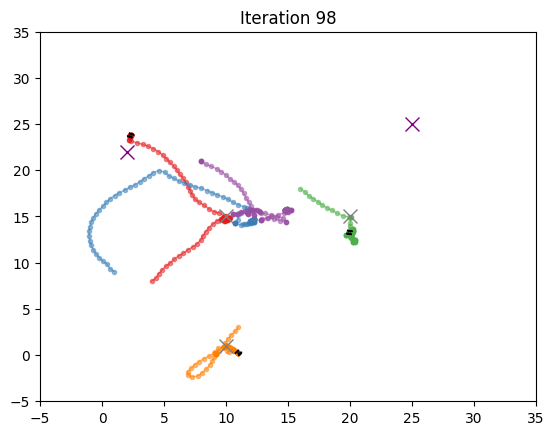

In [53]:
# Re-define the environment and simulation parameters here
interactive = True  # Set to True to display the animation in the notebook
fast_plot = True  # Set to True to use the fast plotter (no icons)
use_ep = True  # Set to True to use EP, False to use the standard algorithm
convergence_type = 'exclusive'  # Set to 'converge' to check for convergence, 'exclusive' to check for separate goals
args = {}
# draft_results = []

random_seed = 7 #2, 3

np.random.seed(random_seed)  # Set random seed
# Set random goals
env_size = 30 # Environment size
iterations_per_episode = 100  # Number of iterations per episode
num_goals = 5 # Number of goals
num_agents = 5  # Number of agents
list_types = ['A','B']
#goals = np.random.uniform(1,env_size-1,size=(num_goals, 2))  # Goal positions
#goals = np.array([[-2,5], [5,5]], dtype=float)
# goals = np.array([[0,0],[env_size-5,0]], dtype=float)  # Goal positions
# goals = np.array([[0.15, 0.1], [0.5,0.55]])

goals = np.array([[25,25],
                  [10,15],
                  [10,1],
                  [20,15],
                  [2,22],
#                  [9,17],
#                  [3,2],
                  ], dtype=float)

agent_positions = np.array([[4, 8, 0],
                            [1, 9, np.pi],
                            [16, 18, 0],
                            [8, 21, np.pi/2],
                            [11, 3, np.pi/0.667],
#                            [15, 14, 0],
#                            [10, 1, np.pi]
                            ], dtype=float)
agent_types = np.array(['A', 'B', 'A', 'B', 'A'])
#agent_positions = np.hstack((np.random.uniform(0,env_size,size=(num_agents, 2)),np.zeros((num_agents,1))))  # Initial agent positions
#agent_positions = np.array([[0,0,0],[5,0,0]], dtype=float)
#agent_positions = np.array([[4.45,4.45,-3*np.pi/4],[3.45,3.5,-3*np.pi/4]], dtype=float)
number_of_heading_options = 8; number_of_velocity_options = 4
args = dict({
    'goals': goals, # Goal positions
    'home_base': np.array([0,0]), # Home base position
    'agent_types': agent_types,#np.repeat('A',num_agents),#np.random.choice(list_types,num_agents),#['A','B','B'],#np.random.choice(list_types,num_agents), # Agent types
    'agent_positions': agent_positions, # Initial agent positions
    'velocity_options': np.linspace(0.0,1,number_of_velocity_options,endpoint=True), # Velocity options
    'num_heading_options': number_of_heading_options, # Number of heading options
    'heading_options': np.linspace(-np.pi/4,np.pi/4,number_of_heading_options,endpoint=True),
    'observation_error_std': 0.0, # Observation error standard deviation
    'num_actions': number_of_heading_options*number_of_velocity_options, # Number of actions
    'env_size': env_size, # Environment size
    'max_distance_measure': env_size + 1,
    'max_heading_measure': np.pi, # Maximum heading measure
    'prior': np.ones(goals.shape[0]) / goals.shape[0], # Prior belief
    'use_ep': use_ep, # Use epistemic planning (2nd order reasoning)
    'greedy': False, # Use greedy action selection
    'horizon': 1, # Horizon for free energy checking
    'mcts_iterations': 100, # Number of MCTS iterations
    'use_mcts': False,
    'use_rhc': False,
    'use_threading': False, #TODO: Implement threading
    'convergence_type': convergence_type, # Convergence type
    'dt': 0.5, # Time step
})

# Check convergence for different types of conergence criterion
if args['convergence_type'] == 'exclusive':
    tuple_elements = [i for i in range(agent_positions.shape[0])]
    configurations = list(itertools.permutations(tuple_elements))
    args['reward_configs'] = configurations # Reward configurations if different goals
else:
    args['reward_configs'] = [tuple(np.repeat(i, num_agents)) for i in range(num_goals)]

# args['reward_configs'] = [(0,1,1), (1,0,1), (1,1,0)]

# Run the simulation
results = aif.run_simulation(args, iterations_per_episode)
print("Final Prior: ", results['priors'])
print("Agent Types: ", args['agent_types'])


# Create animation
if not fast_plot:
    completed_task_img = mpimg.imread('figures/meeting_icon_selected.png')
    not_completed_task_img = mpimg.imread('figures/meeting_icon_not_selected.png')
    plt_sim = aif.PlotSim(num_agents, goals, args['agent_types'], completed_task_img, not_completed_task_img, env_size, padding=5, scale = 0.3)
else:
    plt_sim = aif.PlotSim_fast(num_agents, goals, args['agent_types'],env_size, padding=5, scale = 0.1)
ani = FuncAnimation(plt_sim.fig, plt_sim.update, frames=range(results['iteration']), init_func=plt_sim.init, fargs = (results['plot_args'],), blit=True, repeat=True)

# Save the animation as a video
current_time = datetime.now().strftime("%Y%m%d-%H%M%S")
config_file = ["numRobots", num_agents, "_numGoals", num_goals, "_seed", random_seed, "_EP", args['use_ep'], "_goalType", convergence_type, "_envSize", env_size]
config_file = ''.join([str(elem) for elem in config_file])
if results['converged'] == None and not interactive:
    filepath = pwd + "videos/NO_convergence_" + config_file + ".mp4"
    ani.save(filepath, writer='ffmpeg', fps=3, dpi=200)
    # Save location of the final image
    print("Image saved as: ", filepath)
elif not interactive:
    filepath = pwd + "videos/Converged_" + config_file + ".mp4"
    ani.save(filepath, writer='ffmpeg', fps=3, dpi=200)
    # Save location of the final image
    print("Image saved as: ", filepath)
else:
    display(HTML(ani.to_jshtml())) # Use an interactive backend for animation

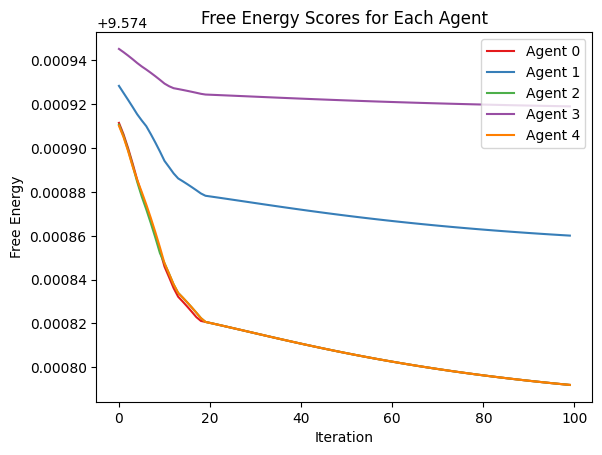

[(0, 1, 2, 3, 4), (0, 1, 2, 4, 3), (0, 1, 3, 2, 4), (0, 1, 3, 4, 2), (0, 1, 4, 2, 3), (0, 1, 4, 3, 2), (0, 2, 1, 3, 4), (0, 2, 1, 4, 3), (0, 2, 3, 1, 4), (0, 2, 3, 4, 1), (0, 2, 4, 1, 3), (0, 2, 4, 3, 1), (0, 3, 1, 2, 4), (0, 3, 1, 4, 2), (0, 3, 2, 1, 4), (0, 3, 2, 4, 1), (0, 3, 4, 1, 2), (0, 3, 4, 2, 1), (0, 4, 1, 2, 3), (0, 4, 1, 3, 2), (0, 4, 2, 1, 3), (0, 4, 2, 3, 1), (0, 4, 3, 1, 2), (0, 4, 3, 2, 1), (1, 0, 2, 3, 4), (1, 0, 2, 4, 3), (1, 0, 3, 2, 4), (1, 0, 3, 4, 2), (1, 0, 4, 2, 3), (1, 0, 4, 3, 2), (1, 2, 0, 3, 4), (1, 2, 0, 4, 3), (1, 2, 3, 0, 4), (1, 2, 3, 4, 0), (1, 2, 4, 0, 3), (1, 2, 4, 3, 0), (1, 3, 0, 2, 4), (1, 3, 0, 4, 2), (1, 3, 2, 0, 4), (1, 3, 2, 4, 0), (1, 3, 4, 0, 2), (1, 3, 4, 2, 0), (1, 4, 0, 2, 3), (1, 4, 0, 3, 2), (1, 4, 2, 0, 3), (1, 4, 2, 3, 0), (1, 4, 3, 0, 2), (1, 4, 3, 2, 0), (2, 0, 1, 3, 4), (2, 0, 1, 4, 3), (2, 0, 3, 1, 4), (2, 0, 3, 4, 1), (2, 0, 4, 1, 3), (2, 0, 4, 3, 1), (2, 1, 0, 3, 4), (2, 1, 0, 4, 3), (2, 1, 3, 0, 4), (2, 1, 3, 4, 0), (2, 1, 4, 0, 

In [46]:
avg_nrg_over_time = results['energy_scores']
num_frames = results['iteration']
energy_results, ending_energy = aif.parse_free_energy_scores(avg_nrg_over_time, num_frames)
aif.plot_energy(energy_results, num_agents)
print(args['reward_configs'])